# Pseudotime

In [9]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
OBJ = "airway-epithelium"
OBJ_V = 'reclustered'
OBJ_PATH= MAIN_DIR / 'data' / 'sub' / OBJ / 'h5ad' / f'{OBJ}-{OBJ_V}.h5ad'

In [10]:
obj = sc.read_h5ad(OBJ_PATH)

In [11]:
LABELS_KEY = 'reclustered_ct'

In [12]:
# Identify basal cells
basal_mask = obj.obs[LABELS_KEY] == "basal"

# Extract the RESOLVI latent representation for all cells
X_latent = obj.obsm["X_resolvi"]

# Calculate the centroid of basal cells in latent space
basal_centroid = X_latent[basal_mask].mean(axis=0)

# Get the integer indices of basal cells in the full AnnData object
basal_indices = np.where(basal_mask)[0]

# Find the basal cell closest to the basal-cell centroid
# This provides a representative basal cell to use as the trajectory root
root_local = np.argmin(
    np.linalg.norm(
        X_latent[basal_indices] - basal_centroid,
        axis=1,
    )
)

# Convert the index within the basal subset back to the index
# within the full AnnData object
root_index = basal_indices[root_local]

# Set the selected basal cell as the root cell for diffusion pseudotime
obj.uns["iroot"] = int(root_index)

In [13]:
# Compute the diffusion map representation of the cells
# This captures gradual transitions in the data and is used by DPT
sc.tl.diffmap(obj)

# Compute diffusion pseudotime (DPT) using the root cell
# previously specified in obj.uns["iroot"]
# Lower values are closer to the basal root; higher values are farther along the inferred trajectory
sc.tl.dpt(obj)

Check pseudotime values

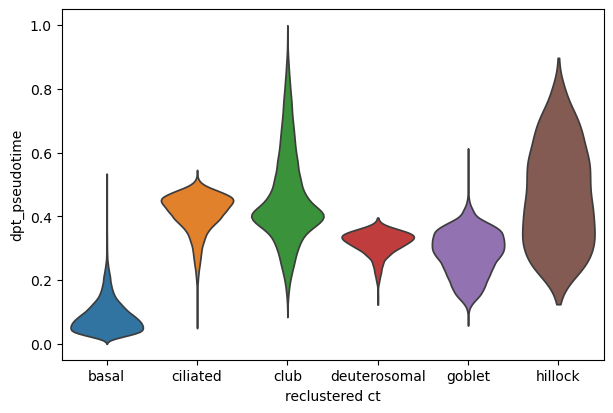

In [14]:
# Check with a violin plot

sc.pl.violin(
    obj,
    "dpt_pseudotime",
    groupby=LABELS_KEY,
    stripplot=False,
)

Check for extreme values

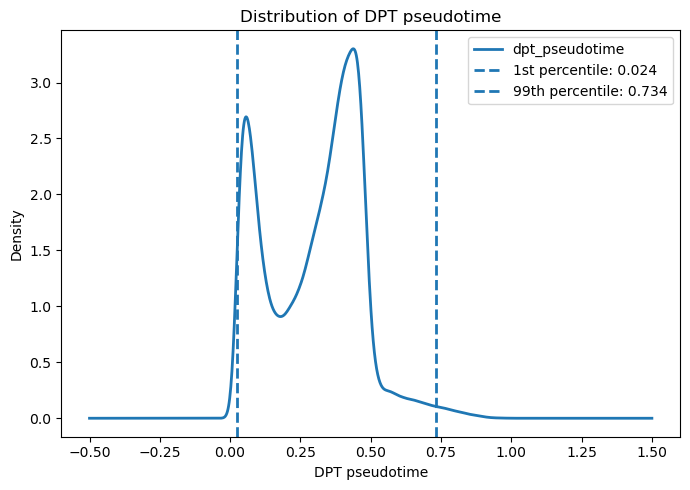

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

pt = obj.obs["dpt_pseudotime"].dropna()

# Calculate percentiles
p01 = pt.quantile(0.01)
p99 = pt.quantile(0.99)

ax = pt.plot(
    kind="kde",
    figsize=(7, 5),
    linewidth=2,
)

# Add vertical percentile lines
ax.axvline(
    p01,
    linestyle="--",
    linewidth=2,
    label=f"1st percentile: {p01:.3f}",
)

ax.axvline(
    p99,
    linestyle="--",
    linewidth=2,
    label=f"99th percentile: {p99:.3f}",
)

ax.set_xlabel("DPT pseudotime")
ax.set_ylabel("Density")
ax.set_title("Distribution of DPT pseudotime")
ax.legend()

plt.tight_layout()
plt.show()

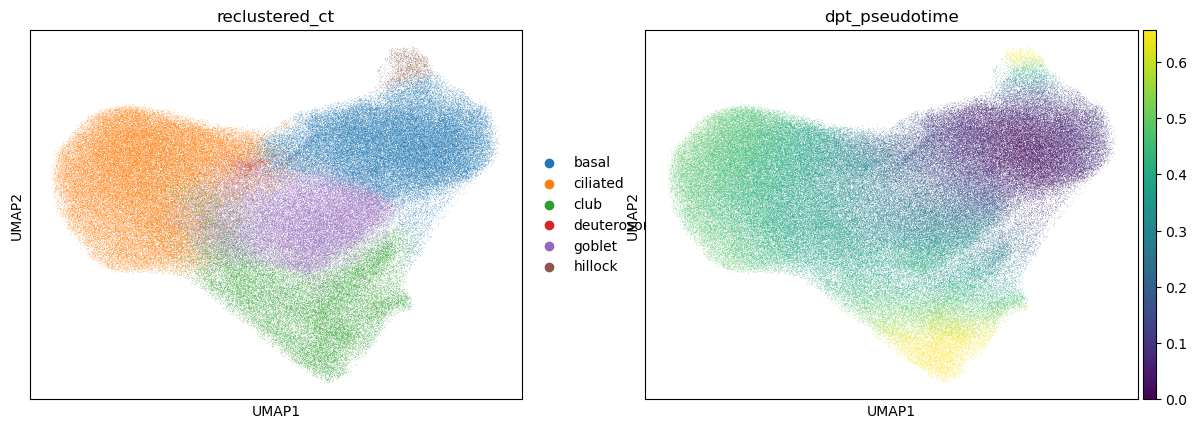

In [20]:
sc.pl.umap(
    obj,
    color=[LABELS_KEY, "dpt_pseudotime"],
    cmap="viridis",
    layer='resolvi_normalized',
    vmax="p98",
    #vmin="p1",
    ncols=2
)